[![Run in Colab](https://colab.research.google.com/assets/colab-badge.svg)](TU_LINK_DE_GITHUB_O_COLAB)

# Notebook IV.1 — Duffing, forma temporal y contenido espectral

Este notebook acompaña la **Ventana computacional IV.1** del Capítulo IV.  
Su propósito es comparar tres miradas complementarias sobre el oscilador de Duffing forzado:

1. la **forma temporal** $x(t)$,
2. el **retrato de fase** $(x,\dot x)$,
3. el **contenido espectral** de la respuesta periódica.

La idea central es observar cómo una **no linealidad cúbica** deforma una oscilación dominada por la frecuencia fundamental e introduce armónicos superiores, en particular el **tercero**.

## 1. Modelo de Duffing forzado

Trabajaremos con la ecuación

$$
\ddot{x} + 2\zeta \omega_0 \dot{x} + \omega_0^2 x + \alpha x^3 = F \cos(\Omega t).
$$

Aquí:

- $\omega_0$ es la frecuencia natural lineal,
- $\zeta$ es el amortiguamiento,
- $\alpha$ controla la no linealidad cúbica,
- $F$ es la amplitud del forzamiento,
- $\Omega$ es la frecuencia de excitación.

En este notebook resolveremos el sistema en el dominio temporal y luego extraeremos una descripción espectral de la respuesta estacionaria.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.fft import rfft, rfftfreq

## 2. Parámetros del sistema

Puedes modificar estos parámetros para explorar distintos regímenes.  
Un valor positivo de $\alpha$ suele asociarse con **hardening**.

In [3]:
# Parámetros del modelo
zeta = 0.05
omega0 = 1.0
alpha = 1.0
F = 0.20
Omega = 1.0

# Integración temporal
n_periods_total = 250
points_per_period = 400

T = 2 * np.pi / Omega
t_final = n_periods_total * T
n_points = n_periods_total * points_per_period + 1
t_eval = np.linspace(0.0, t_final, n_points)

# Condiciones iniciales
x0 = 0.0
v0 = 0.0

## 3. Integración temporal

Escribimos el sistema de segundo orden como un sistema de primer orden:

$$
\dot{x} = v,
\qquad
\dot{v} = -2\zeta \omega_0 v - \omega_0^2 x - \alpha x^3 + F\cos(\Omega t).
$$

Usaremos `solve_ivp` para integrar.

In [4]:
def duffing_rhs(t, y, zeta, omega0, alpha, F, Omega):
    x, v = y
    dxdt = v
    dvdt = -2*zeta*omega0*v - omega0**2*x - alpha*x**3 + F*np.cos(Omega*t)
    return [dxdt, dvdt]

sol = solve_ivp(
    duffing_rhs,
    t_span=(0.0, t_final),
    y0=[x0, v0],
    t_eval=t_eval,
    args=(zeta, omega0, alpha, F, Omega),
    rtol=1e-8,
    atol=1e-10,
    method="RK45",
)

t = sol.t
x = sol.y[0]
v = sol.y[1]

## 4. Aislar la respuesta estacionaria

Como el sistema arranca desde una condición inicial arbitraria, al principio aparecen transitorios.  
Para estudiar la órbita periódica forzada, descartaremos una gran parte inicial de la simulación y analizaremos solo los últimos periodos.

In [5]:
n_periods_keep = 40
samples_keep = n_periods_keep * points_per_period

t_ss = t[-samples_keep:]
x_ss = x[-samples_keep:]
v_ss = v[-samples_keep:]

# versión centrada en tiempo para graficar mejor
t_ss_shift = t_ss - t_ss[0]

## 5. Forma temporal de la respuesta

Aquí observamos la señal estacionaria $x(t)$.  
Si la respuesta fuera puramente sinusoidal, su forma sería casi una sola frecuencia.  
La deformación visible sugiere ya la presencia de armónicos.

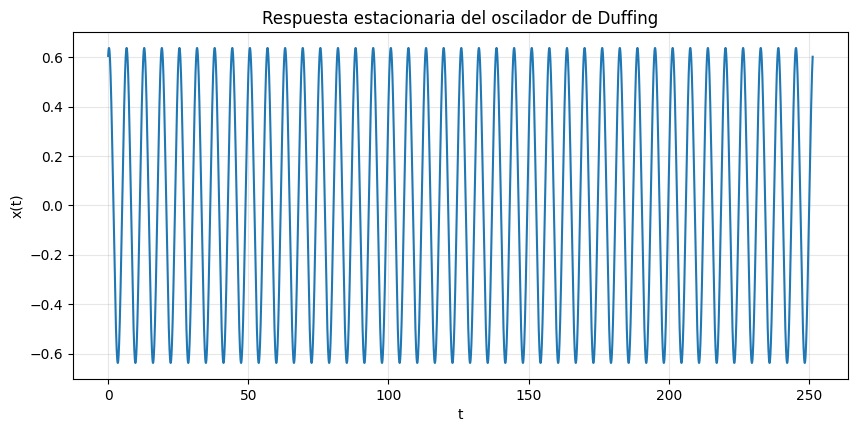

In [6]:
plt.figure(figsize=(10, 4.5))
plt.plot(t_ss_shift, x_ss)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Respuesta estacionaria del oscilador de Duffing")
plt.grid(True, alpha=0.3)
plt.show()

## 6. Retrato de fase

El retrato de fase $(x,\dot{x})$ proporciona otra forma de mirar la órbita periódica.  
En régimen estacionario, la trayectoria debería cerrarse aproximadamente sobre una curva periódica.

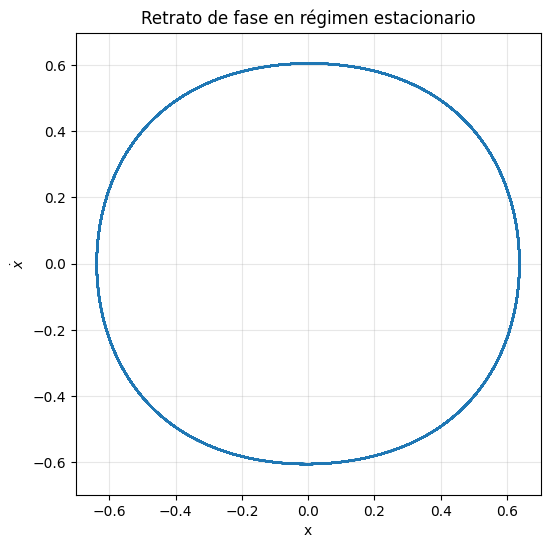

In [7]:
plt.figure(figsize=(6, 6))
plt.plot(x_ss, v_ss)
plt.xlabel("x")
plt.ylabel(r"$\dot{x}$")
plt.title("Retrato de fase en régimen estacionario")
plt.grid(True, alpha=0.3)
plt.axis("equal")
plt.show()

## 7. Espectro armónico mediante FFT

Calculamos ahora una transformada discreta de Fourier sobre la parte estacionaria de la señal.  
Como el interés del capítulo está en la organización armónica, representaremos el espectro en función de la frecuencia normalizada respecto a la excitación.

Queremos ver si, además del armónico fundamental, aparecen armónicos superiores con amplitud apreciable.

In [8]:
dt = t_ss[1] - t_ss[0]
N = len(x_ss)

Xf = rfft(x_ss)
freqs_hz = rfftfreq(N, d=dt)
freqs_rad = 2 * np.pi * freqs_hz
harmonic_order = freqs_rad / Omega

amplitude = 2.0 * np.abs(Xf) / N
amplitude[0] = np.abs(Xf[0]) / N

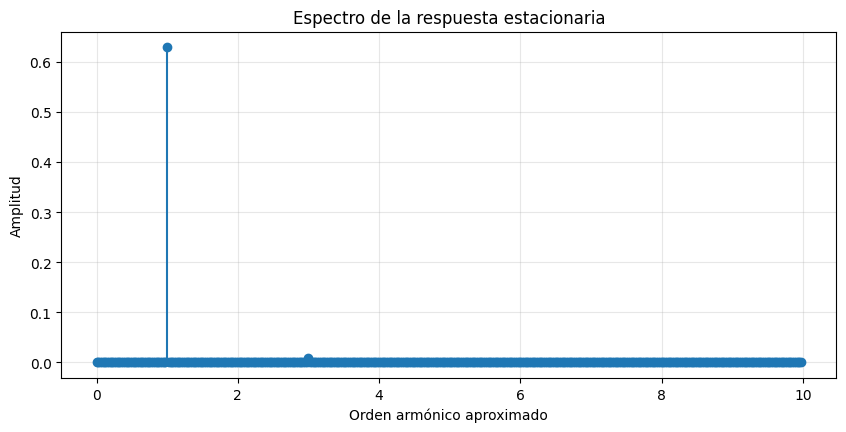

In [9]:
max_harmonic_to_show = 10
mask = harmonic_order <= max_harmonic_to_show

plt.figure(figsize=(10, 4.5))
plt.stem(harmonic_order[mask], amplitude[mask], basefmt=" ")
plt.xlabel("Orden armónico aproximado")
plt.ylabel("Amplitud")
plt.title("Espectro de la respuesta estacionaria")
plt.grid(True, alpha=0.3)
plt.show()

## 8. Extraer los armónicos más cercanos a enteros

Como la simulación es numérica y la ventana temporal es finita, la FFT no siempre cae exactamente sobre enteros.  
Aquí buscamos, para cada armónico $k$, el bin más cercano a $k\Omega$.

In [10]:
def harmonic_amplitude(k, harmonic_order, amplitude):
    idx = np.argmin(np.abs(harmonic_order - k))
    return harmonic_order[idx], amplitude[idx]

rows = []
for k in range(0, 8):
    hk, ak = harmonic_amplitude(k, harmonic_order, amplitude)
    rows.append((k, hk, ak))

print("k | orden detectado | amplitud")
print("-" * 34)
for k, hk, ak in rows:
    print(f"{k:1d} | {hk:14.6f} | {ak:10.6f}")

k | orden detectado | amplitud
----------------------------------
0 |       0.000000 |   0.000000
1 |       1.000000 |   0.629653
2 |       2.000000 |   0.000000
3 |       3.000000 |   0.008425
4 |       4.000000 |   0.000000
5 |       5.000000 |   0.000108
6 |       6.000000 |   0.000000
7 |       7.000000 |   0.000001


## 9. Aproximación de primer armónico a partir de la señal simulada

Una forma muy simple de construir una aproximación de primer armónico es proyectar la señal estacionaria sobre
$\cos(\Omega t)$ y $\sin(\Omega t)$.

Es decir, buscamos

$$
x_1(t) = a \cos(\Omega t) + b \sin(\Omega t).
$$

Luego comparamos esa reconstrucción con la señal real.

In [11]:
theta = Omega * t_ss_shift
c1 = np.cos(theta)
s1 = np.sin(theta)

a = 2 / len(theta) * np.sum(x_ss * c1)
b = 2 / len(theta) * np.sum(x_ss * s1)

x_1harm = a * c1 + b * s1
A1 = np.sqrt(a**2 + b**2)
phi1 = np.arctan2(-b, a)

print(f"a = {a:.6f}")
print(f"b = {b:.6f}")
print(f"Amplitud fundamental estimada A1 = {A1:.6f}")
print(f"Fase estimada phi1 = {phi1:.6f} rad")

a = 0.600573
b = 0.189141
Amplitud fundamental estimada A1 = 0.629653
Fase estimada phi1 = -0.305100 rad


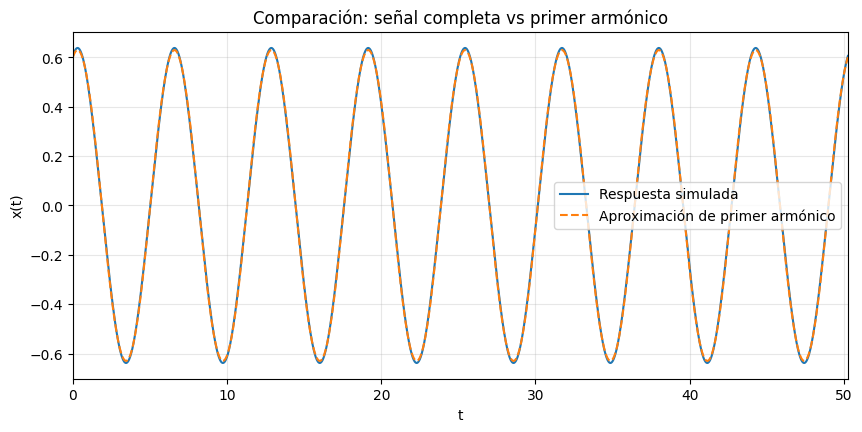

In [12]:
plt.figure(figsize=(10, 4.5))
plt.plot(t_ss_shift, x_ss, label="Respuesta simulada")
plt.plot(t_ss_shift, x_1harm, "--", label="Aproximación de primer armónico")
plt.xlim(0, 8*T)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Comparación: señal completa vs primer armónico")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 10. Interpretación

Este resultado permite observar varias ideas centrales del capítulo:

- La respuesta sigue siendo **periódica**, pero no necesariamente sinusoidal.
- La no linealidad cúbica redistribuye energía hacia armónicos superiores.
- El **primer armónico** sigue capturando una parte importante de la respuesta, pero no toda.
- El espectro ofrece una lectura estructurada de la órbita periódica.

Desde este punto de vista, el balance armónico puede leerse como una forma de imponer compatibilidad dinámica dentro de una arquitectura espectral truncada.

## 11. Ejercicios de exploración sugeridos

1. Cambia el valor de $\alpha$ y observa cómo cambia el contenido del tercer armónico.
2. Incrementa la fuerza de excitación $F$ y compara la deformación temporal.
3. Cambia la frecuencia de excitación $\Omega$ para acercarte o alejarte de resonancia.
4. Repite el análisis con una ventana temporal más larga y observa la mejora en la identificación espectral.
5. Compara los resultados para $\alpha>0$ y $\alpha<0$.

## 12. Hacia el siguiente notebook

Este notebook es una primera exploración visual y numérica.  
El siguiente paso natural es construir el **residual armónico** de manera explícita y resolverlo con **Newton--Raphson**, enlazando directamente con la formulación algebraica del balance armónico.